# 04 · Word2Vec

**Parte 3 — embeddings densos.** TF-IDF sigue sin saber que "rey" y
"monarca" significan casi lo mismo: son sinónimos, pero ocupan posiciones
distintas del vector y su coseno da 0. Además, con 50 000 columnas casi
todas las palabras terminan pareciendo igual de "lejanas" entre sí (la
maldición de la dimensionalidad). Word2Vec resuelve ambos problemas
**aprendiendo** los números en vez de contarlos.

## Hipótesis distribucional

> "Una palabra se conoce por la compañía que mantiene." — J. R. Firth, 1957

"café" y "té" casi nunca aparecen en la misma frase, pero comparten vecinos
("bebí", "taza", "caliente"). Si los vectores se construyen a partir de esos
vecinos compartidos, "café" y "té" terminan próximos aunque nunca hayan
coincidido en un texto — el significado se deriva de la estadística de uso,
no de un diccionario.

## Disperso vs. denso: la misma palabra, dos formatos

Un vector disperso (Bag-of-Words) enciende una sola posición por palabra;
uno denso tiene un valor en cada posición y muchas menos dimensiones.

In [11]:
import numpy as np
import pandas as pd


def similitud_coseno(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return a.dot(b) / (np.linalg.norm(a) * np.linalg.norm(b))


# Embeddings de juguete (4 dimensiones) solo para ilustrar la mecánica
embeddings_juguete = pd.DataFrame(
    {
        "gato": [0.91, 0.12, 0.83, 0.05],
        "perro": [0.88, 0.19, 0.79, 0.09],
        "sismo": [0.07, 0.94, 0.11, 0.88],
    }
).T
embeddings_juguete.columns = ["dim1", "dim2", "dim3", "dim4"]
embeddings_juguete

,dim1,dim2,dim3,dim4
gato,0.91,0.12,0.83,0.05
perro,0.88,0.19,0.79,0.09
sismo,0.07,0.94,0.11,0.88


In [12]:
cos_gato_perro = similitud_coseno(embeddings_juguete.loc["gato"], embeddings_juguete.loc["perro"])
cos_gato_sismo = similitud_coseno(embeddings_juguete.loc["gato"], embeddings_juguete.loc["sismo"])
print(f"cos(gato, perro) = {cos_gato_perro:.3f}")
print(f"cos(gato, sismo) = {cos_gato_sismo:.3f}")

cos(gato, perro) = 0.997
cos(gato, sismo) = 0.195


Con TF-IDF, "gato" y "perro" daban coseno 0 al no compartir ningún término
del vocabulario. Con embeddings alcanzan 0.997: comparten vecinos, aunque no
compartan ninguna letra.

## Cómo se consiguen esos números

Nadie escribe a mano los valores de un embedding. Se entrena una red con una
tarea de mentira — "dada una palabra, adivina qué palabras la rodean" — y al
terminar se descarta la tarea: lo que interesa no es la predicción, sino la
tabla de pesos que la red ajustó por dentro. Como el propio texto contiene
la respuesta, no hace falta etiquetar nada (**auto-supervisado**): se puede
entrenar con millones de oraciones sin que nadie anote una sola línea.

Existen dos variantes de la tarea: **Skip-gram** (entrada: la palabra
central → predice sus vecinos) y **CBOW** (entrada: los vecinos → predice la
palabra central). Skip-gram es más lento de entrenar pero aprende mejor las
palabras poco frecuentes, y es la variante que se usa por defecto en la
mayoría de modelos publicados.

**El obstáculo:** para cada ejemplo de entrenamiento, predecir la palabra
vecina exacta entre un vocabulario de un millón de palabras obliga a un
softmax sobre esas mismas un millón de opciones — carísimo, y se repite
miles de millones de veces. La solución, **negative sampling**, cambia la
pregunta: en vez de "¿cuál de las 1 000 000 de palabras sigue a 'gato'?" se
pregunta "¿este par de palabras salió del texto o me lo inventé?" — una
pregunta de sí/no que solo toca un puñado de vectores (1 real + ~10 falsos)
en cada paso, no el vocabulario entero. Levy & Goldberg (2014) probaron que
entrenar así produce, en el límite, los mismos vectores que factorizar la
enorme tabla de coocurrencias palabra-palabra del corpus — el entrenamiento
la factoriza sin llegar a construirla.

## Entrenar un Word2Vec propio

Se entrena sobre los 619 comentarios de clientes con `gensim`. Es un corpus
minúsculo para este método (Word2Vec necesita millones de oraciones para
generalizar bien), así que sirve para ver la mecánica, no para obtener
vectores de calidad — eso se resuelve con un modelo preentrenado más abajo.

In [13]:
import spacy
from gensim.models import Word2Vec

nlp = spacy.load("es_core_news_sm")
comentarios = pd.read_csv("../data/comentarios.csv")


def tokenizar(textos):
    return [
        [t.lemma_ for t in doc if t.is_alpha and not t.is_stop]
        for doc in nlp.pipe((str(x).lower() for x in textos), batch_size=64)
    ]


oraciones = tokenizar(comentarios["texto_comentario"])

modelo_propio = Word2Vec(
    sentences=oraciones,
    vector_size=50,  # dimensión pequeña, acorde al tamaño del corpus
    window=5,
    min_count=3,
    sg=1,  # skip-gram
    workers=4,
    seed=42,
)
print(f"Vocabulario aprendido: {len(modelo_propio.wv):,} palabras")
print(modelo_propio.wv.most_similar("laptop", topn=5))

Vocabulario aprendido: 410 palabras
[('rendimiento', 0.9952747821807861), ('manejar', 0.9951295256614685), ('juego', 0.9950977563858032), ('vibrante', 0.9948370456695557), ('frustrante', 0.9946812987327576)]


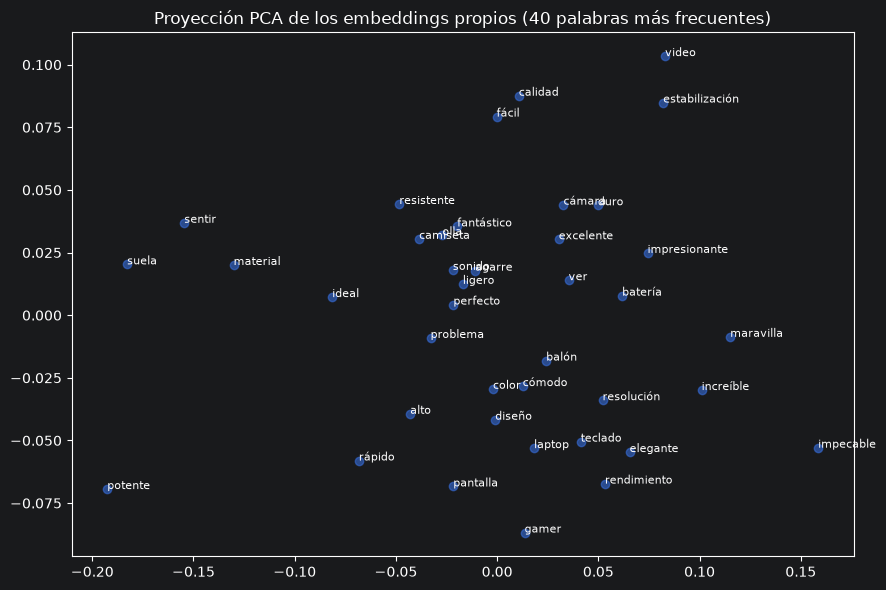

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

palabras_frecuentes = modelo_propio.wv.index_to_key[:40]
vectores = modelo_propio.wv[palabras_frecuentes]
coords = PCA(n_components=2, random_state=42).fit_transform(vectores)

plt.figure(figsize=(9, 6))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6)
for (x, y), palabra in zip(coords, palabras_frecuentes):
    plt.annotate(palabra, (x, y), fontsize=8)
plt.title("Proyección PCA de los embeddings propios (40 palabras más frecuentes)")
plt.tight_layout()
plt.show()

Palabras que aparecen en contextos parecidos (categorías de producto,
adjetivos de opinión) tienden a agruparse, aunque con solo 619 comentarios
el resultado es ruidoso.

## Aritmética de significados

Si los vectores codifican significado, sumarlos y restarlos debería dar
resultados con sentido: $\vec{rey} - \vec{hombre} + \vec{mujer} \approx
\vec{reina}$. El corpus propio es demasiado chico para que esto emerja con
calidad, así que se usa un modelo preentrenado sobre miles de millones de
palabras: **GloVe** (Pennington et al., 2014), una variante de la misma
familia de embeddings densos.

## Ejercicio 02 — Analogías vectoriales

**Objetivo:** ¿la analogía es una propiedad real del espacio vectorial, o un
efecto del método de consulta?

In [15]:
import gensim.downloader as api

wv = api.load("glove-wiki-gigaword-100")  # 400k palabras en inglés, 100 dimensiones
print(f"Vocabulario preentrenado: {len(wv):,} palabras")

Vocabulario preentrenado: 400,000 palabras


### 1. `most_similar` con términos del dominio

In [16]:
for termino in ["laptop", "phone", "camera"]:
    print(f"{termino}: {wv.most_similar(termino, topn=5)}")

laptop: [('laptops', 0.8518658876419067), ('computers', 0.7559927105903625), ('phones', 0.7229112386703491), ('portable', 0.7157840728759766), ('desktop', 0.7085692286491394)]
phone: [('telephone', 0.9113394021987915), ('cellphone', 0.8122149109840393), ('phones', 0.8030568361282349), ('mobile', 0.7307462692260742), ('mail', 0.7292180061340332)]
camera: [('cameras', 0.8474850058555603), ('screen', 0.7547301054000854), ('video', 0.6977447271347046), ('screens', 0.6788257956504822), ('microphone', 0.6621578335762024)]


### 2. Reproducir la analogía con la librería

In [17]:
resultado_libreria = wv.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
print("king - man + woman ≈")
for palabra, score in resultado_libreria:
    print(f"  {palabra:12} {score:.3f}")

king - man + woman ≈
  queen        0.770
  monarch      0.684
  throne       0.676
  daughter     0.659
  princess     0.652


### 3. Repetirla a mano con numpy, sin excluir los vectores de entrada

`most_similar` excluye por defecto las palabras que aparecen en la consulta
(`king`, `woman`, `man`). Repitiendo el cálculo a mano y buscando entre
**todo** el vocabulario se ve qué tan real es el efecto.

In [18]:
vector_resultado = wv["king"] - wv["man"] + wv["woman"]

matriz = wv.vectors  # (vocab, dim)
normas = np.linalg.norm(matriz, axis=1) * np.linalg.norm(vector_resultado)
cosenos = matriz @ vector_resultado / normas

top_idx = np.argsort(cosenos)[::-1][:6]
print("Vecinos más cercanos a (king - man + woman), sin excluir nada:")
for i in top_idx:
    print(f"  {wv.index_to_key[i]:12} {cosenos[i]:.3f}")

Vecinos más cercanos a (king - man + woman), sin excluir nada:
  king         0.855
  queen        0.783
  monarch      0.693
  throne       0.683
  daughter     0.681
  prince       0.671


Sin el filtro, "king" vuelve a aparecer entre los primeros resultados: la
resta desplaza el vector hacia "queen", pero no lo suficiente para dejar
atrás a la palabra original. El efecto es real (queen aparece muy arriba,
con un coseno alto) aunque el filtro de `most_similar` lo exagera un poco.

### 4. Coseno entre sinónimos, antónimos y pares sin relación

In [19]:
pares = [
    ("car", "automobile", "sinónimos"),
    ("hot", "cold", "antónimos"),
    ("happy", "sad", "antónimos"),
    ("computer", "banana", "sin relación"),
]
for a, b, tipo in pares:
    print(f"cos({a}, {b}) = {wv.similarity(a, b):.3f}   [{tipo}]")

cos(car, automobile) = 0.683   [sinónimos]
cos(hot, cold) = 0.725   [antónimos]
cos(happy, sad) = 0.680   [antónimos]
cos(computer, banana) = 0.121   [sin relación]


Los antónimos ("hot"/"cold") quedan sorprendentemente cerca — casi tan cerca
como los sinónimos. Tiene sentido con la hipótesis distribucional: "the
coffee is hot" y "the coffee is cold" comparten exactamente el mismo
contexto, así que el modelo los coloca en la misma zona del espacio. La
similitud vectorial captura **relación temática**, no necesariamente
"significan lo mismo".

**Siguiente:** `05_transformers-sbert.ipynb` — un vector distinto para cada
sentido de una palabra, según la frase en la que aparece.